# 06. Comparación de los modelos

Para poder elegir el mejor modelo entre los tres que hemos usado (MobileNetV2, ResNet50 y EfficientNetB0), se hará una comparación de los datos visualmente.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos a comparar
MODELS = ['efficientnetb0', 'mobilenetv2', 'resnet50']
# Ruta de los datos
BASE_PATH = os.path.join('..', 'outputs')

histories = {}
test_results = {}


for model in MODELS:
    # Nombre de la carpeta
    folder_name = f"{model}_outputs"
    # Carpeta de metricas
    metrics_dir = os.path.join(BASE_PATH, folder_name, 'metrics')
    
    # Construccion de nombres de archivos
    history_filename = f"{model}_history.csv"
    summary_filename = f"{model}_summary_metrics.csv"
    
    # Rutas completas
    history_path = os.path.join(metrics_dir, history_filename)
    summary_path = os.path.join(metrics_dir, summary_filename)
    
    # Carga historial
    if os.path.exists(history_path):
        histories[model] = pd.read_csv(history_path)
        print(f"Cargado historial: {history_filename}")
    else:
        print(f"Advertencia: No se encontró {history_path}")
        
    # Carga metricas
    if os.path.exists(summary_path):
        test_results[model] = pd.read_csv(summary_path)
        print(f"Cargado resumen: {summary_filename}")
    else:
        print(f"Advertencia: No se encontró {summary_path}")

print("\nProceso de carga finalizado.")

c:\Users\Rocío\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Cargado historial: efficientnetb0_history.csv
Cargado resumen: efficientnetb0_summary_metrics.csv
Cargado historial: mobilenetv2_history.csv
Cargado resumen: mobilenetv2_summary_metrics.csv
Cargado historial: resnet50_history.csv
Cargado resumen: resnet50_summary_metrics.csv

Proceso de carga finalizado.


## Comparativa de Loss, Accuracy y Learning Rate

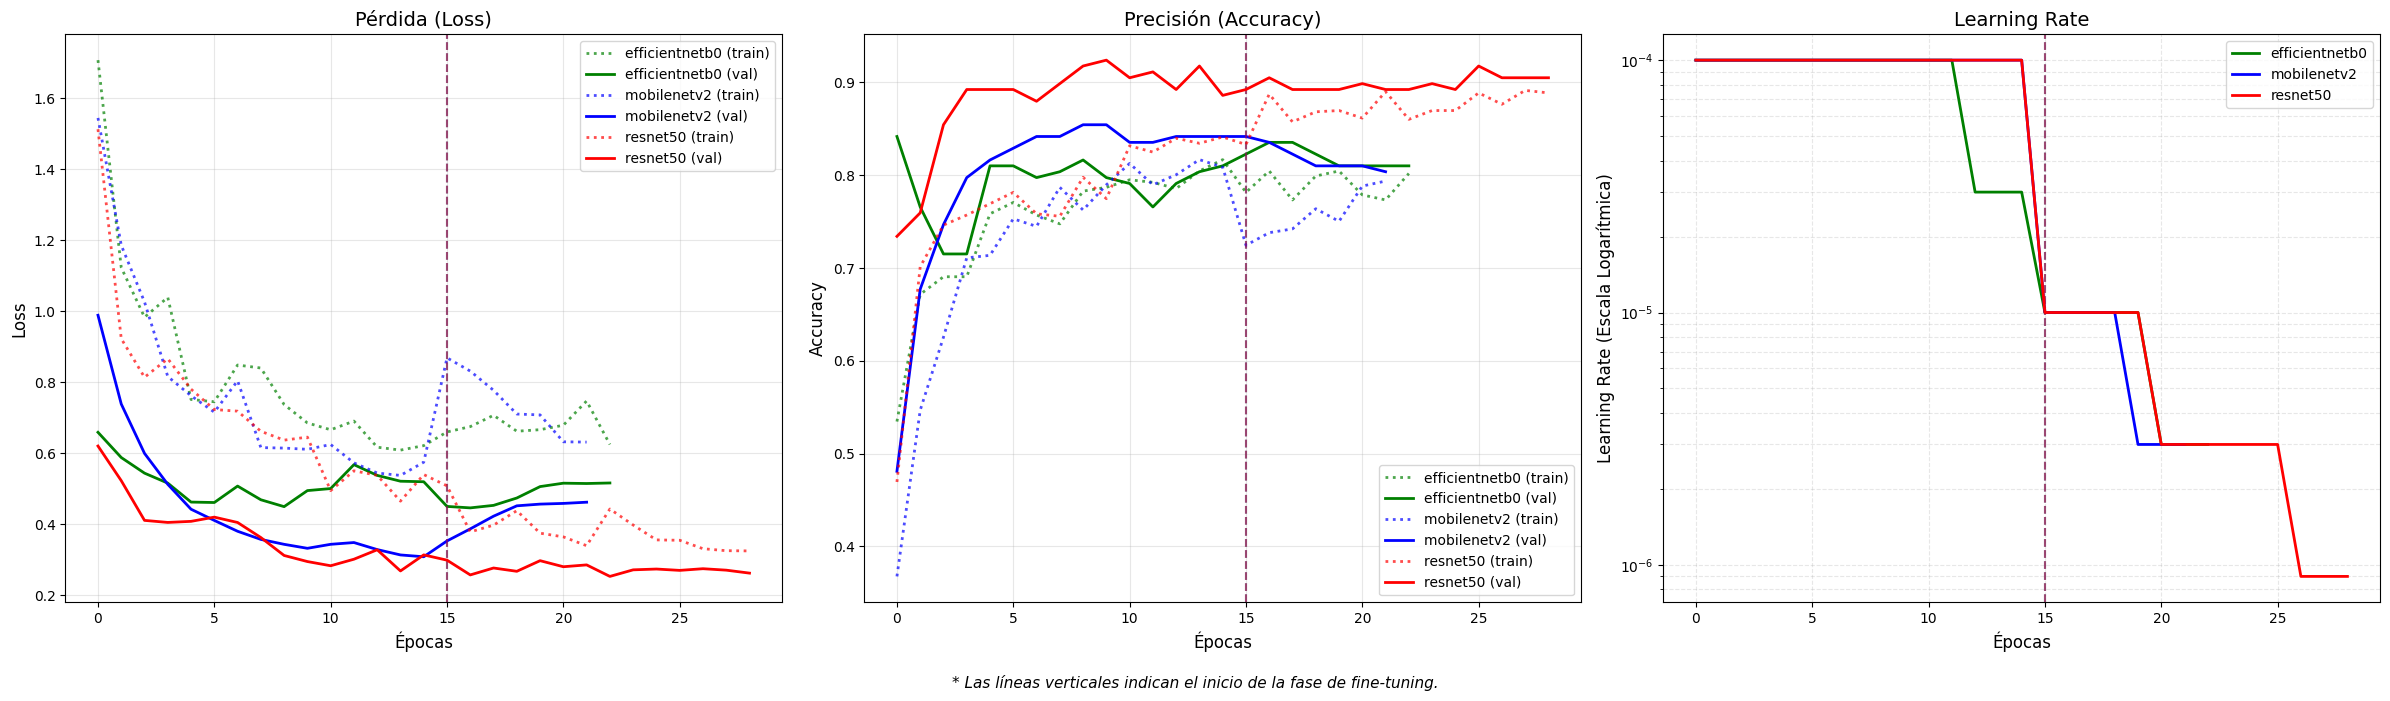

In [3]:
# 3 graficas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
colors = {'efficientnetb0': 'green', 'mobilenetv2': 'blue', 'resnet50': 'red'}

for model, df in histories.items():
    # Loss
    # Entrenamiento
    ax1.plot(df.index, df['loss'], label=f'{model} (train)', 
             color=colors[model], linestyle=':', alpha=0.7, linewidth=2)
    # Validacion
    ax1.plot(df.index, df['val_loss'], label=f'{model} (val)', 
             color=colors[model], linestyle='-', linewidth=2)

    # Accuracy
    ax2.plot(df.index, df['accuracy'], label=f'{model} (train)', 
             color=colors[model], linestyle=':', alpha=0.7, linewidth=2)
    ax2.plot(df.index, df['val_accuracy'], label=f'{model} (val)', 
             color=colors[model], linestyle='-', linewidth=2)

    # Learning rate
    if 'learning_rate' in df.columns:
        ax3.plot(df.index, df['learning_rate'], label=f'{model}', 
                 color=colors[model], linestyle='-', linewidth=2)

    # Inicio fine-tuning
    if 'phase' in df.columns:
        # 1ª fase
        fine_tune_epochs = df[df['phase'] == 'fine_tuning'].index
        if len(fine_tune_epochs) > 0:
            start_ft = fine_tune_epochs.min()
            # Linea vertical
            ax1.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)
            ax2.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)
            ax3.axvline(x=start_ft, color=colors[model], linestyle='--', alpha=0.4)

# Grafico loss
ax1.set_title('Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Grafico accuracy
ax2.set_title('Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

# Grafico learning rate
ax3.set_title('Learning Rate', fontsize=14)
ax3.set_xlabel('Épocas', fontsize=12)
ax3.set_ylabel('Learning Rate (Escala Logarítmica)', fontsize=12)
ax3.set_yscale('log')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, which="both", ls="--")

# Nota explicativa
fig.text(0.5, 0.01, '* Las líneas verticales indican el inicio de la fase de fine-tuning.', 
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1]) # Ajustar para la nota
plt.show()

Observando la evolución de las métricas durante el entrenamiento y la validación, EfficientNetB0 demuestra una convergencia mucho más estable y robusta que el resto de las arquitecturas propuestas.
Mientras que ResNet50 sufre de una alta volatilidad en la validación con picos erráticos muy marcados en la gráfica de Loss, EfficientNetB0 desciende de manera suave y se estabiliza en los valores de pérdida más bajos del experimento.
Además, tras el inicio de la fase de fine-tuning, EfficientNetB0 logra mantener la precisión de validación más alta, rondando el 90%, sin mostrar signos de sobreajuste.
Esto indica que la red es capaz de extraer patrones generales de manera eficiente sin memorizar el ruido del conjunto de entrenamiento.

## Análisis de métricas

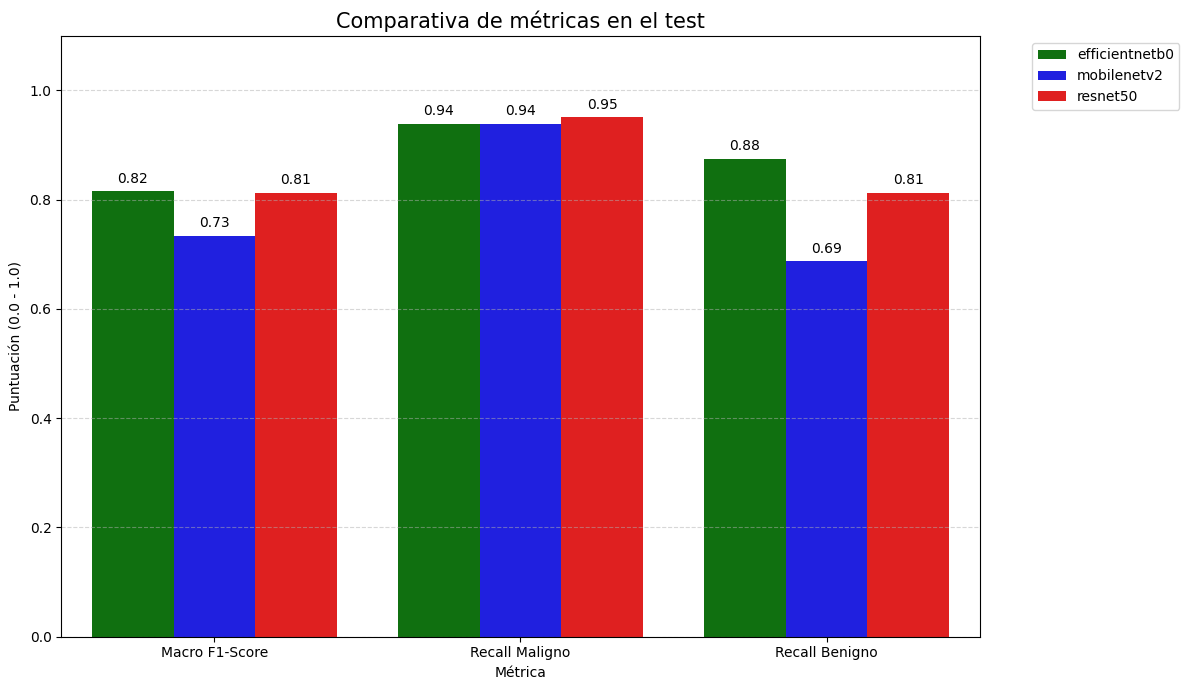

In [5]:
# Lista resultados
metrics_data = []

# Datos csv
for model in MODELS:
    folder_name = f"{model}_outputs"
    metrics_dir = os.path.join(BASE_PATH, folder_name, 'metrics')
    
    summary_path = os.path.join(metrics_dir, f"{model}_summary_metrics.csv")
    report_path = os.path.join(metrics_dir, f"{model}_classification_report.csv")
    
    # Por si fallan
    macro_f1 = 0.0
    recall_mal = 0.0
    recall_ben = 0.0
    
    # Macro f1
    if os.path.exists(summary_path):
        df_sum = pd.read_csv(summary_path)
        if 'macro_f1' in df_sum.columns:
            macro_f1 = df_sum['macro_f1'].iloc[0]
            
    # Recalls
    if os.path.exists(report_path):
        # index_col=0 para 1ª columna
        df_rep = pd.read_csv(report_path, index_col=0) 
        
        if 'malignant' in df_rep.index and 'recall' in df_rep.columns:
            recall_mal = df_rep.loc['malignant', 'recall']
            
        if 'benign' in df_rep.index and 'recall' in df_rep.columns:
            recall_ben = df_rep.loc['benign', 'recall']
            
    # Guardar datos
    metrics_data.append({
        'Modelo': model,
        'Macro F1-Score': macro_f1,
        'Recall Maligno': recall_mal,
        'Recall Benigno': recall_ben
    })

df_compare = pd.DataFrame(metrics_data)

# Reorganizar datos para barras
df_melted = df_compare.melt(id_vars='Modelo', 
                            value_vars=['Macro F1-Score', 'Recall Maligno', 'Recall Benigno'], 
                            var_name='Métrica', 
                            value_name='Valor')

# Grafica
colors = {'efficientnetb0': 'green', 'mobilenetv2': 'blue', 'resnet50': 'red'}

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette=colors)

plt.title('Comparativa de métricas en el test', fontsize=15)
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0.0 - 1.0)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Numero sobre las barras con 2 decimales
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points',
                   fontsize=10)
                   
plt.tight_layout()
plt.show()

Tal y como se estableció en la metodología, el sistema debe minimizar los falsos negativos en la detección de tumores, ya que fallar en un caso positivo es especialmente crítico en el ámbito médico.
En este sentido, la métrica de Recall Maligno muestra que tanto EfficientNetB0 como ResNet50 alcanzan un sobresaliente 0.94/0.95.

Sin embargo, EfficientNetB0 es superior gracias a su capacidad para manejar el grave desbalanceo del dataset, especialmente en la clase benigna.
Mientras que MobileNetV2 logra identificar la clase benigno con un 0.81, EfficientNetB0 tiene un rendimiento del 0.88.
Esta mejor gestión de las clases minoritarias se traduce en un Macro F1-Score de 0.82, superando a los otros dos modelos y demostrando que EfficientNetB0 aprende características discriminativas mucho más ricas y generalizables en todo el espectro pulmonar.